# BÀI THỰC HÀNH 2: MẠNG NEURAL TÍCH CHẬP

<b>Hướng dẫn nộp bài:</b> Các bạn commit và push code lên github, sử dụng file txt đặt tên theo cú pháp <MSSV>.txt chứa đường link dẫn đến github của bài thực hành và nộp file txt này tên courses..

Bộ dữ liệu sử dụng: [VinaFood21 dataset](https://arxiv.org/abs/2108.02929).

Link download: https://drive.google.com/file/d/1UpZOf0XlwvB4rKpyZ35iwTA8oWHqDBbR/view?usp=share_link.

### Import libraries

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import os
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D, GlobalAveragePooling2D, Dense, Flatten, Concatenate, Input, Dropout
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

C:\Users\PC\anaconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.0 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.0 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\PC\anaconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.0 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations in the next r

### Load data

In [6]:
# Định nghĩa các generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
)

In [7]:
# Load dữ liệu 
INPUT_SHAPE = (224, 224)
BATCH_SIZE = 32
TRAIN_DIR = 'vinafood21/train'
TEST_DIR = 'vinafood21/test'
NUM_CLASSES = 21

train = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=INPUT_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=INPUT_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=INPUT_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 8051 images belonging to 21 classes.
Found 2003 images belonging to 21 classes.
Found 6683 images belonging to 21 classes.


* Kích thước ảnh đầu vào 224 x 224 giữ lại đủ thông tin cần thiết cho việc phân loại hình ảnh và tối ưu chi phí tính toán cho GoogleNet.

### Bài 2: Xây dựng mô hình GoogLeNet. Huấn luyện và đánh giá mô hình GoogLeNet trên 4 độ đo precision, recall và F1 (sử dụng Adam làm optimizer).

**Inception Blocks**

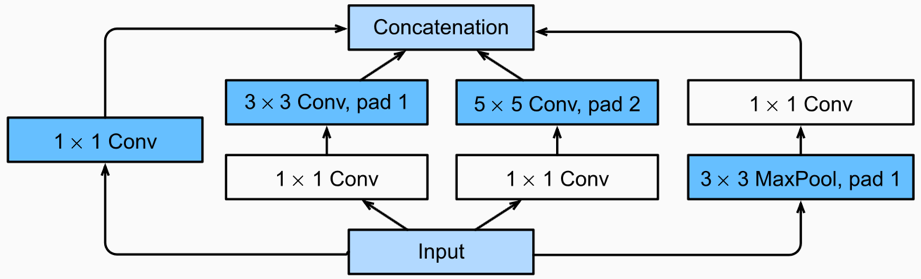

**GoogLeNet (Multi-branch Network)**

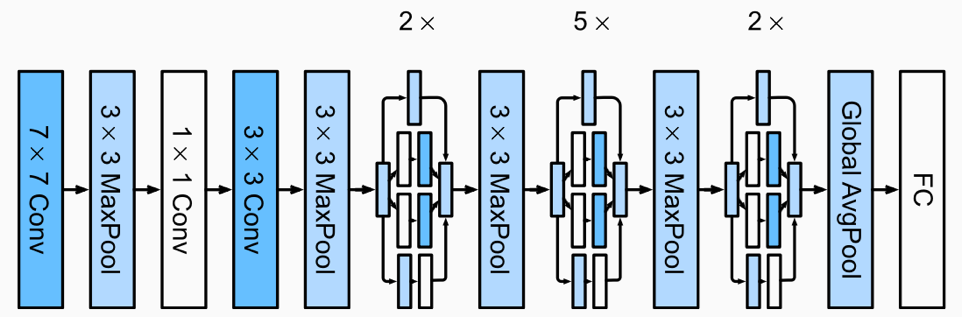

In [10]:
def inception_module(x, f1x1, f3x3_r, f3x3, f5x5_r, f5x5, fpool_p):
    branch_1 = Conv2D(f1x1, (1, 1), padding='same', activation='relu')(x)

    branch_2 = Conv2D(f3x3_r, (1, 1), padding='same', activation='relu')(x)
    branch_2 = Conv2D(f3x3, (3, 3), padding='same', activation='relu')(branch_2)

    branch_3 = Conv2D(f5x5_r, (1, 1), padding='same', activation='relu')(x)
    branch_3 = Conv2D(f5x5, (5, 5), padding='same', activation='relu')(branch_3)
    
    branch_4 = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    branch_4 = Conv2D(fpool_p, (1, 1), padding='same', activation='relu')(branch_4)

    return Concatenate(axis=-1)([branch_1, branch_2, branch_3, branch_4])


def build_googlenet(input_shape, num_classes):
    input_shape = input_shape[0], input_shape[1], 3
    input_layer = Input(shape=input_shape)
    x = input_layer
    
    x = Conv2D(64, (7, 7), strides=(2, 2), padding='same', activation='relu')(input_layer)
    
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    x = Conv2D(64, (1, 1), padding='same', activation='relu')(x)
    
    x = Conv2D(192, (3, 3), padding='same', activation='relu')(x)
    
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    
    x = inception_module(x, 64, 96, 128, 16, 32, 32)
    x = inception_module(x, 128, 128, 192, 32, 96, 64)
    
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    x = inception_module(x, 192, 96, 208, 16, 48, 64)
    x = inception_module(x, 160, 112, 224, 24, 64, 64)
    x = inception_module(x, 128, 128, 256, 24, 64, 64)
    x = inception_module(x, 112, 144, 288, 32, 64, 64)
    x = inception_module(x, 256, 160, 320, 32, 128, 128)
    
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    
    x = inception_module(x, 256, 160, 320, 32, 128, 128)
    
    x = inception_module(x, 384, 192, 384, 48, 128, 128)
    
    x = AveragePooling2D((7, 7), strides=(1, 1))(x)
    x = Dropout(0.4)(x)
    x = Flatten()(x)
    output_layer = Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs=input_layer, outputs=output_layer)

In [11]:
googlenet = build_googlenet(INPUT_SHAPE, NUM_CLASSES)
googlenet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 112, 112, 64)      │           9,472 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 56, 56, 64)        │               0 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 56, 56, 64)        │           4,160 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 56, 56, 192)       │         110,784 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 28, 28, 192)       │               0 │ conv2d_2[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 28, 28, 96)        │          18,528 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 28, 28, 16)        │           3,088 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 28, 28, 192)       │               0 │ max_pooling2d_1[0][0]      │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 28, 28, 64)        │          12,352 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 28, 28, 128)       │         110,720 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 28, 28, 32)        │          12,832 │ conv2d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_8 (Conv2D)             │ (None, 28, 28, 32)        │           6,176 │ max_pooling2d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 28, 28, 256)       │               0 │ conv2d_3[0][0],            │
│                               │                           │                 │ conv2d_5[0][0],            │
│                               │                           │                 │ conv2d_7[0][0],            │
│                               │                           │                 │ conv2d_8[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_10 (Conv2D)            │ (None, 28, 28, 128)       │          32,89

 Total params: 5,995,077 (22.87 MB)

 Trainable params: 5,995,077 (22.87 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Biên dịch Mô hình
googlenet.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Định nghĩa EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

EPOCHS = 2

In [13]:
# Huấn luyện Mô hình
history = googlenet.fit(
    train,
    epochs=EPOCHS,
    validation_data=val,
    callbacks=[early_stopping]
)

C:\Users\PC\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
177/252 ━━━━━━━━━━━━━━━━━━━━ 5:30 4s/step - accuracy: 0.0789 - loss: 3.0027 

C:\Users\PC\anaconda3\Lib\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


252/252 ━━━━━━━━━━━━━━━━━━━━ 1311s 5s/step - accuracy: 0.0883 - loss: 2.9887 - val_accuracy: 0.0909 - val_loss: 2.9800
Epoch 2/2
252/252 ━━━━━━━━━━━━━━━━━━━━ 1237s 5s/step - accuracy: 0.0913 - loss: 2.9804 - val_accuracy: 0.0909 - val_loss: 2.9752


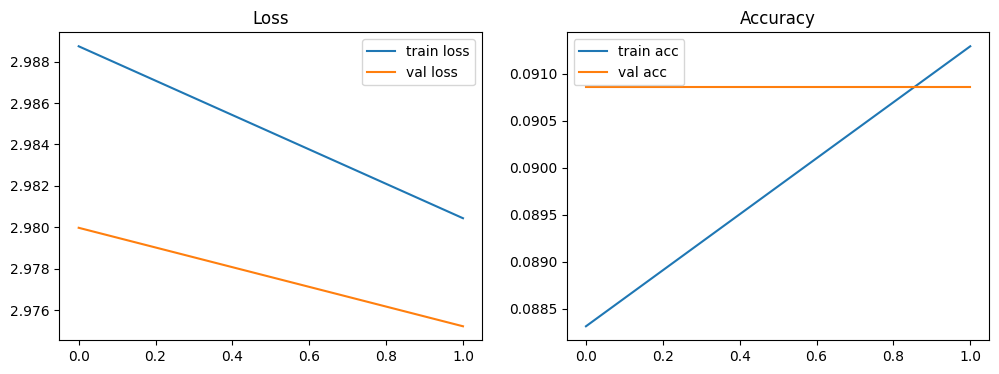

In [14]:
# Plot kết quả (accuracy và loss)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [15]:
# Đánh giá trên tập test
loss, acc = googlenet.evaluate(test, verbose=0)
test.reset() 
Y_pred = googlenet.predict(test)
y_pred_classes = np.argmax(Y_pred, axis=1)
y_true = test.classes 
class_names = list(test.class_indices.keys())

209/209 ━━━━━━━━━━━━━━━━━━━━ 514s 2s/step 


In [16]:
# Báo cáo phân loại
report = classification_report(y_true, y_pred_classes, target_names=class_names, output_dict=True)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"Precision (Macro Avg): {report['macro avg']['precision']:.4f}")
print(f"Recall (Macro Avg): {report['macro avg']['recall']:.4f}")
print(f"F1-score (Macro Avg): {report['macro avg']['f1-score']:.4f}")

print(classification_report(y_true, y_pred_classes, target_names=class_names))

Loss: 2.9755
Accuracy: 0.0908
Precision (Macro Avg): 0.0043
Recall (Macro Avg): 0.0476
F1-score (Macro Avg): 0.0079
                  precision    recall  f1-score   support

        banh-can       0.00      0.00      0.00       241
        banh-hoi       0.09      1.00      0.17       607
    banh-mi-chao       0.00      0.00      0.00       289
        banh-tet       0.00      0.00      0.00       364
 banh-trang-tron       0.00      0.00      0.00       309
          banh-u       0.00      0.00      0.00       176
        banh-uot       0.00      0.00      0.00       561
       bap-nuong       0.00      0.00      0.00       143
          bo-kho       0.00      0.00      0.00       338
       bo-la-lot       0.00      0.00      0.00       458
       bot-chien       0.00      0.00      0.00       276
           ca-ri       0.00      0.00      0.00       171
    canh-kho-qua       0.00      0.00      0.00       290
   canh-khoai-mo       0.00      0.00      0.00       198
        ga-nu

C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\m

* GoogLeNet đang cho thấy hiệu suất kém, với độ chính xác 0.909 val_accuracy và 0.913 train_accuracy, trong khi độ mất mát vẫn còn rất cao. Mặc dù mô hình đang học loss giảm, nhưng tốc độ học quá chậm và độ chính xác cuối cùng chỉ cao hơn một chút so với tỷ lệ đoán ngẫu nhiên, cho thấy mô hình không thể trích xuất được các đặc trưng có ý nghĩa từ dữ liệu. Các chỉ số trên test cũng cho thấy mô hình không thực sự hoạt động hiệu quả.
* GoogLeNet có hiệu suất thấp có thể là do việc thiếu Batch Normalization và Residual Connections khiến quá trình huấn luyện kém ổn định và chậm hơn, đồng thời việc thiếu Residual Connection làm cho mô hình khó có thể được mở rộng độ sâu mà vẫn giữ được hiệu suất truyền gradient, dẫn đến giới hạn về độ chính xác tối đa. Sô epoch thấp chưa thể hiện rõ xu hướng học của mô hình, tốc dộ học chưa tối ưu được hiệu suất mô hình. 
* Giải pháp: Thêm Batch Normalization vào mạng để ổn định hóa và tăng tốc độ huấn luyện; áp dụng Residual Connections để mạng trở nên sâu hơn mà không gặp vấn đề gradient biến mất hay suy giảm hiệu suất, đồng thời có thể tận dụng các cải tiến module tích chập khác như Factorization; có thể sử dụng chuẩn hóa Z-score Normalization để tiền xử lí trước khi đưa vào huấn luyện.

In [18]:
# Chuẩn hóa (Normalization)
temp_gen = ImageDataGenerator().flow_from_directory(
    TRAIN_DIR,
    target_size=INPUT_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

all_data = []
num_samples = temp_gen.samples
steps = np.ceil(num_samples / BATCH_SIZE)

for i in range(int(steps)):
    data_batch = next(temp_gen)[0]
    all_data.append(data_batch)

all_data = np.concatenate(all_data, axis=0)
MEAN = np.mean(all_data, axis=(0, 1, 2))
STD = np.std(all_data, axis=(0, 1, 2))

def zero_center_preprocess(image):
    image = image / 255.0
    return (image - MEAN) / (STD)

Found 10054 images belonging to 21 classes.



KeyboardInterrupt

